## Yolo
### 객체 탐지

In [1]:
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt

In [2]:
img = Image.open('parkjihyun.jpg')

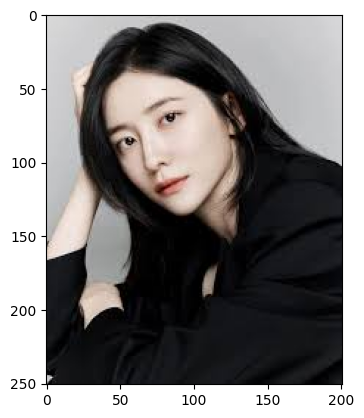

In [3]:
plt.imshow(img)

In [4]:
model = YOLO('yolo11n.pt')

In [5]:
result = model(img)


0: 640x544 1 person, 93.3ms
Speed: 3.9ms preprocess, 93.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 544)


In [6]:
import cv2

In [ ]:
# 4. 결과 시각화 및 화면 표시 
for result in result: # 탐지된 객체의 바운딩 박스가 그려진 이미지 가져오기 
    annotated_frame = result.plot() # 결과 화면에 출력 
    cv2.imshow("YOLO Detection Result", annotated_frame) 
    cv2.waitKey(0) 
    
cv2.destroyAllWindows()

--- 
Yolo 실습

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


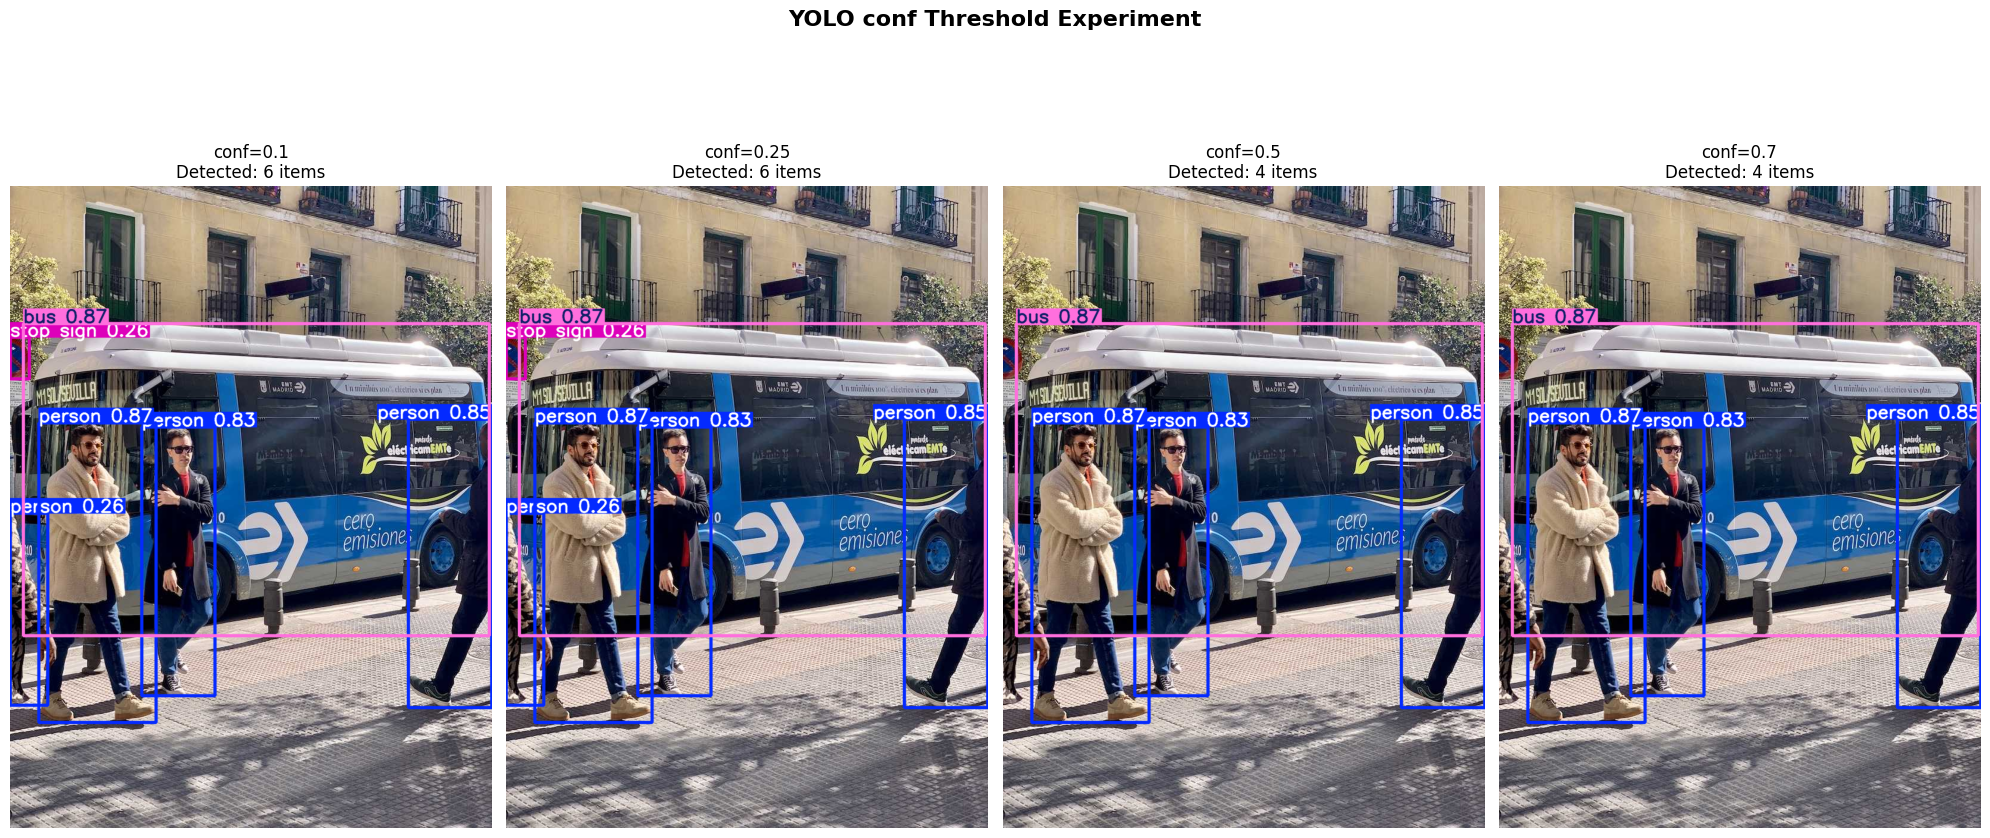

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


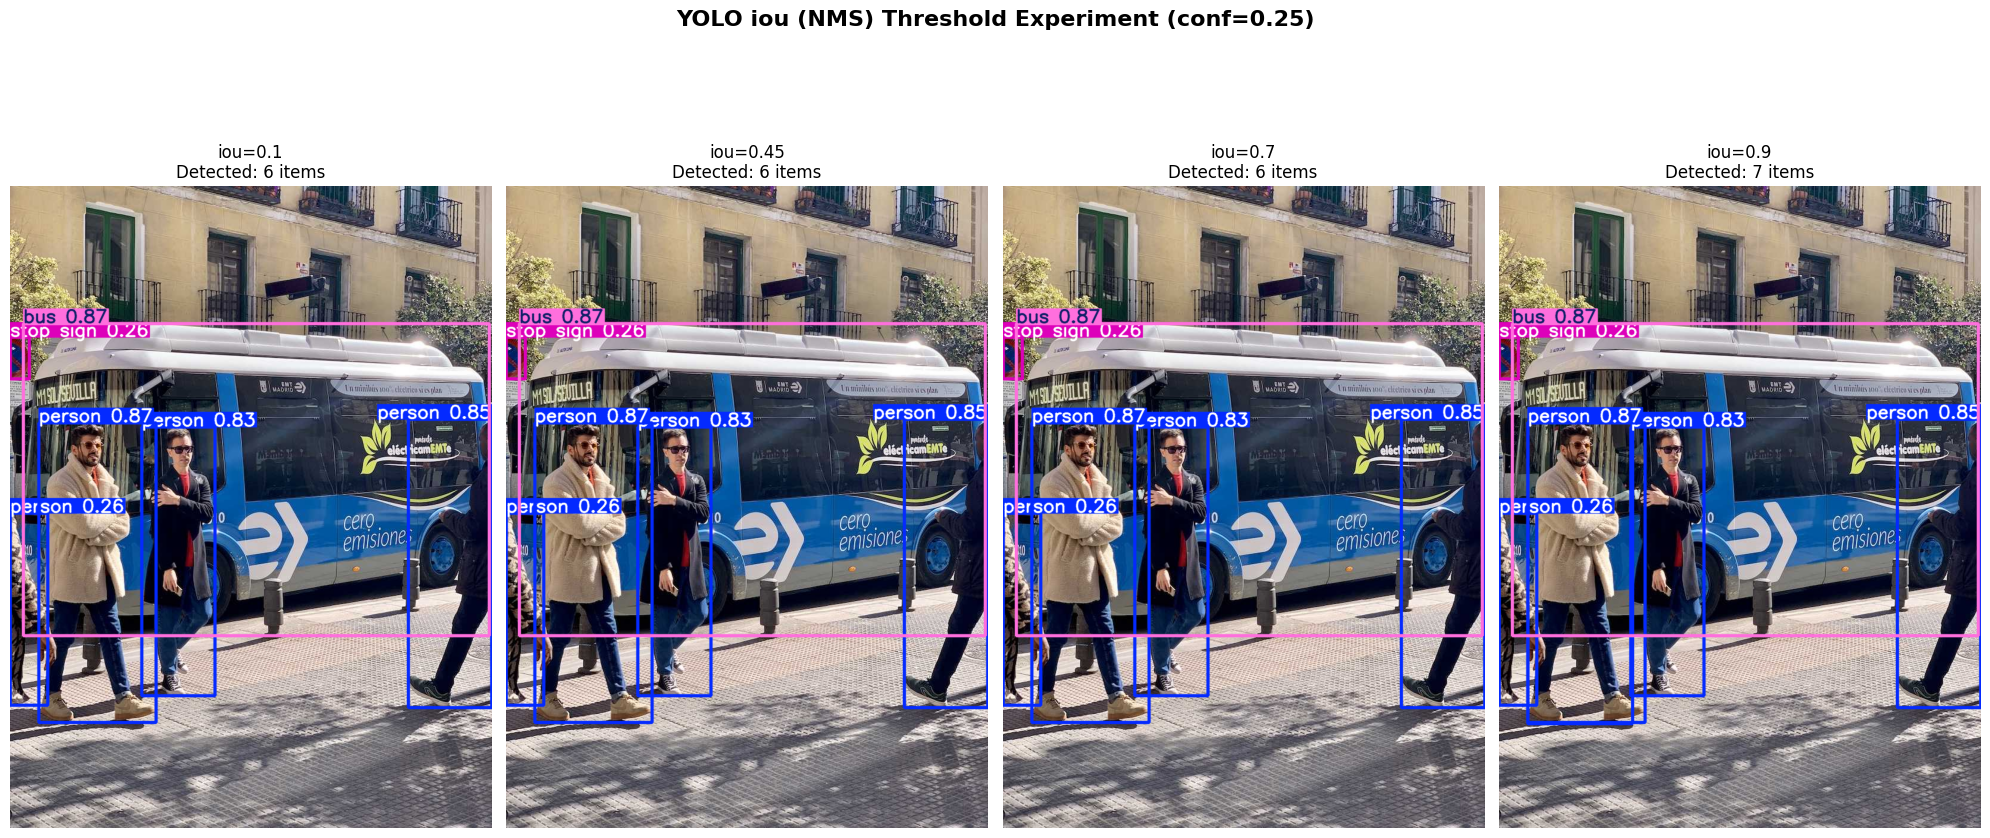

In [1]:
# 필요 시 라이브러리 설치: !pip install ultralytics opencv-python matplotlib
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. 사전 학습된 YOLOv8 모델 로드 (가장 가벼운 nano 버전)
model = YOLO('yolov8n.pt')

# 2. 실험에 사용할 샘플 이미지 다운로드 또는 로드
# 여기서는 YOLO 내부의 기본 샘플 이미지('bus.jpg')를 사용합니다.
image_path = 'https://ultralytics.com/images/bus.jpg'

# ---------------------------------------------------------
# 실험 1: conf [0.1, 0.25, 0.5, 0.7] 임계값 비교 실험
# ---------------------------------------------------------
conf_thresholds = [0.1, 0.25, 0.5, 0.7]

fig, axs = plt.subplots(1, 4, figsize=(20, 10))
fig.suptitle("YOLO conf Threshold Experiment", fontsize=16, weight='bold')

for i, conf_val in enumerate(conf_thresholds):
    # 모델 추론 (지정된 conf 임계값 적용)
    results = model(image_path, conf=conf_val, verbose=False)
    
    # 결과 시각화 이미지 가져오기 (BGR -> RGB 변환)
    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
    
    # 탐지된 객체 개수 파악
    num_objects = len(results[0].boxes)
    
    # 그리기
    axs[i].imshow(res_rgb)
    axs[i].set_title(f"conf={conf_val}\nDetected: {num_objects} items")
    axs[i].axis('off')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 실험 2: 추가 추천 변수 - iou 임계값 비교 실험 (기본 conf=0.25 고정)
# ---------------------------------------------------------
iou_thresholds = [0.1, 0.45, 0.7, 0.9] # iou가 높을수록 겹친 박스를 많이 허용함

fig, axs = plt.subplots(1, 4, figsize=(20, 10))
fig.suptitle("YOLO iou (NMS) Threshold Experiment (conf=0.25)", fontsize=16, weight='bold')

for i, iou_val in enumerate(iou_thresholds):
    # 모델 추론 (conf는 고정하고 iou 임계값만 가변)
    results = model(image_path, conf=0.25, iou=iou_val, verbose=False)
    
    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
    
    num_objects = len(results[0].boxes)
    
    axs[i].imshow(res_rgb)
    axs[i].set_title(f"iou={iou_val}\nDetected: {num_objects} items")
    axs[i].axis('off')

plt.tight_layout()
plt.show()

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
최적 임계값 적용 후 최종 탐지된 사물 개수: 6개


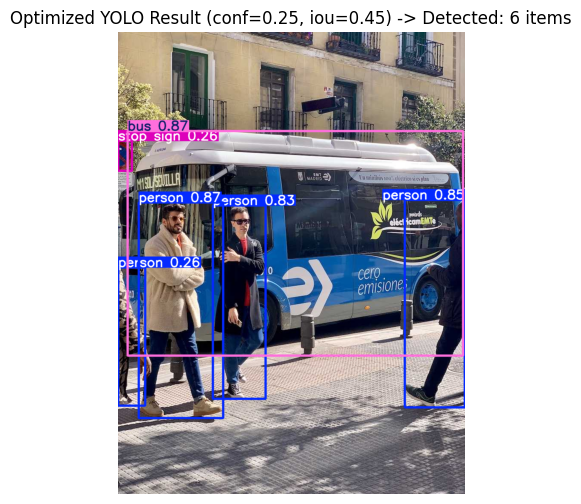

In [2]:
# ==============================================================================
# [YOLO 하이퍼파라미터 최적화 실험 결론 및 임계값 설정]
#
# 📌 최적의 임계값 설정 이유 (골디락스 존: Goldilocks Zone)
#
# 1. conf=0.25 설정 이유:
#    - conf 임계값이 0.1일 때는 확실하지 않은 표지판(stop sign 0.26)이나 보행자 노이즈가 잡힘.
#    - conf 임계값이 0.5 이상으로 높아지면 실제 보행자(왼쪽 사람)까지 미탐지(놓침)되는 현상 발생.
#    - 따라서, 오탐지(False Positive)와 미탐지(False Negative) 사이의 최적의 타협점으로 0.25를 선택함.
#
# 2. iou=0.45 설정 이유:
#    - iou 임계값이 0.9로 극단적으로 높아지면 중복 제거(NMS)가 작동하지 않아 
#      동일한 객체(오른쪽 사람 다리 부근)에 박스가 중복으로 겹쳐 그려지는 지저분한 결과 발생.
#    - iou 임계값이 너무 낮으면 겹쳐 있는 서로 다른 사물을 하나로 오인해 지울 위험이 있음.
#    - 따라서, 중복 박스를 완벽히 제거하면서 개별 객체를 독립적으로 유지하는 표준값인 0.45를 선택함.
#
# 📝 한 줄 요약: "본 이미지셋에서는 conf=0.25, iou=0.45 조합이 탐지 누락과 박스 중복을 모두 방지하는 가장 깔끔한 접점이다."
# ==============================================================================

# 3. 실험을 통해 도출한 최적의 접점 임계값(conf=0.25, iou=0.45) 적용하여 예측 실행
results = model(image_path, conf=0.25, iou=0.45, verbose=False)

# 4. 결과 객체 수 확인 및 시각화
num_objects = len(results[0].boxes)
print(f"최적 임계값 적용 후 최종 탐지된 사물 개수: {num_objects}개")

# BGR 이미지를 RGB로 변환하여 Matplotlib으로 깔끔하게 출력
res_plotted = results[0].plot()
res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(res_rgb)
plt.title(f"Optimized YOLO Result (conf=0.25, iou=0.45) -> Detected: {num_objects} items")
plt.axis('off')
plt.show()